## Import libraries and data loading
## Data inspection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('Job_Market_Dataset.csv')
df

,Job_ID,Job_Title,Job_Category,Location,Year,Company,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA,Employment_Type
0,1,Data Analyst,Data,Bangalore,2023,TCS,1,4,8,Full-Time
1,2,Data Scientist,Data,Bangalore,2024,Infosys,2,8,18,Full-Time
2,3,Business Analyst,Business,Hyderabad,2023,Accenture,2,6,12,Full-Time
3,4,ML Engineer,AI/ML,Bangalore,2025,Google,3,15,30,Full-Time
4,5,Power BI Developer,BI,Chennai,2024,Wipro,1,5,10,Full-Time
5,6,Data Analyst,Data,Hyderabad,2024,Deloitte,1,4,9,Full-Time
6,7,Data Scientist,Data,Pune,2025,Amazon,3,12,25,Full-Time
7,8,AI Engineer,AI/ML,Bangalore,2025,Microsoft,3,18,35,Full-Time
8,9,SQL Developer,Database,Chennai,2023,HCL,1,3,7,Full-Time
9,10,Python Developer,Software,Hyderabad,2023,Tech Mahindra,2,5,10,Full-Time


In [3]:
df.head()

,Job_ID,Job_Title,Job_Category,Location,Year,Company,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA,Employment_Type
0,1,Data Analyst,Data,Bangalore,2023,TCS,1,4,8,Full-Time
1,2,Data Scientist,Data,Bangalore,2024,Infosys,2,8,18,Full-Time
2,3,Business Analyst,Business,Hyderabad,2023,Accenture,2,6,12,Full-Time
3,4,ML Engineer,AI/ML,Bangalore,2025,Google,3,15,30,Full-Time
4,5,Power BI Developer,BI,Chennai,2024,Wipro,1,5,10,Full-Time


In [4]:
df.tail()

,Job_ID,Job_Title,Job_Category,Location,Year,Company,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA,Employment_Type
35,36,Data Scientist,Data,Chennai,2024,Freshworks,2,8,16,Full-Time
36,37,Business Analyst,Business,Delhi,2025,Amazon,3,9,18,Full-Time
37,38,SQL Developer,Database,Pune,2024,Infosys,1,4,8,Full-Time
38,39,Data Analyst,Data,Bangalore,2024,PhonePe,1,6,12,Full-Time
39,40,ML Engineer,AI/ML,Hyderabad,2025,Tesla,4,18,32,Full-Time


# Data Exploration

In [5]:
df.dtypes

Job_ID                       int64
Job_Title                      str
Job_Category                   str
Location                       str
Year                         int64
Company                        str
Experience_Required_Years    int64
Salary_Min_LPA               int64
Salary_Max_LPA               int64
Employment_Type                str
dtype: object

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Job_ID                     40 non-null     int64
 1   Job_Title                  40 non-null     str  
 2   Job_Category               40 non-null     str  
 3   Location                   40 non-null     str  
 4   Year                       40 non-null     int64
 5   Company                    40 non-null     str  
 6   Experience_Required_Years  40 non-null     int64
 7   Salary_Min_LPA             40 non-null     int64
 8   Salary_Max_LPA             40 non-null     int64
 9   Employment_Type            40 non-null     str  
dtypes: int64(5), str(5)
memory usage: 4.8 KB


In [7]:
df.describe()

,Job_ID,Year,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA
count,40.000000,40.00000,40.000000,40.000000,40.00000
mean,20.500000,2024.07500,2.125000,8.750000,17.32500
std,11.690452,0.79703,1.066687,5.057363,9.41463
min,1.000000,2023.00000,0.000000,3.000000,6.00000
25%,10.750000,2023.00000,1.000000,4.750000,9.75000
50%,20.500000,2024.00000,2.000000,7.000000,15.00000
75%,30.250000,2025.00000,3.000000,11.250000,21.25000
max,40.000000,2025.00000,4.000000,20.000000,40.00000


## Data cleaning 

In [8]:
df.isnull().sum()

Job_ID                       0
Job_Title                    0
Job_Category                 0
Location                     0
Year                         0
Company                      0
Experience_Required_Years    0
Salary_Min_LPA               0
Salary_Max_LPA               0
Employment_Type              0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## EDA (Getting in_sides from the dataframe)

In [10]:
da = pd.DataFrame(df.groupby("Job_Title")["Salary_Max_LPA"].mean().sort_values(ascending= False).head(5))
print(da)

                Salary_Max_LPA
Job_Title                     
AI Researcher             40.0
AI Consultant             38.0
AI Engineer               30.5
ML Engineer               25.2
Data Scientist            21.8


AI Reaschers are  the highest paid job


In [11]:
db = pd.DataFrame(df.groupby("Company")["Job_ID"].count().sort_values(ascending= False).head(5))
print(db)

           Job_ID
Company          
Amazon          3
Infosys         2
Accenture       1
Byjus           1
BCG             1


 Amazon is providing more jobs


In [12]:
dc=df.groupby("Job_Title")["Experience_Required_Years"].mean().sort_values(ascending=False).head()
dc

Job_Title
AI Consultant          4.0
AI Researcher          4.0
AI Engineer            3.0
Data Engineer          3.0
Power BI Consultant    3.0
Name: Experience_Required_Years, dtype: float64

 AI Consultant role requires highest experience

In [13]:
de = pd.DataFrame(df.groupby("Location")["Job_Title"].count())
print(de)

           Job_Title
Location            
Bangalore         12
Chennai            5
Delhi              4
Hyderabad          8
Mumbai             5
Pune               6


Banglore has the maximum vacancies

In [14]:
dg=df.groupby("Year")["Job_Title"].count()
dg

Year
2023    11
2024    15
2025    14
Name: Job_Title, dtype: int64

2024 has more vancianes

In [15]:
di = pd.DataFrame(df.groupby("Company")["Salary_Max_LPA"].mean().sort_values(ascending= False).head(5))
print(di)

           Salary_Max_LPA
Company                  
OpenAI               40.0
McKinsey             38.0
Microsoft            35.0
Meta                 35.0
Tesla                32.0


OpenAI  Provide more salary than others

# Data Visualization

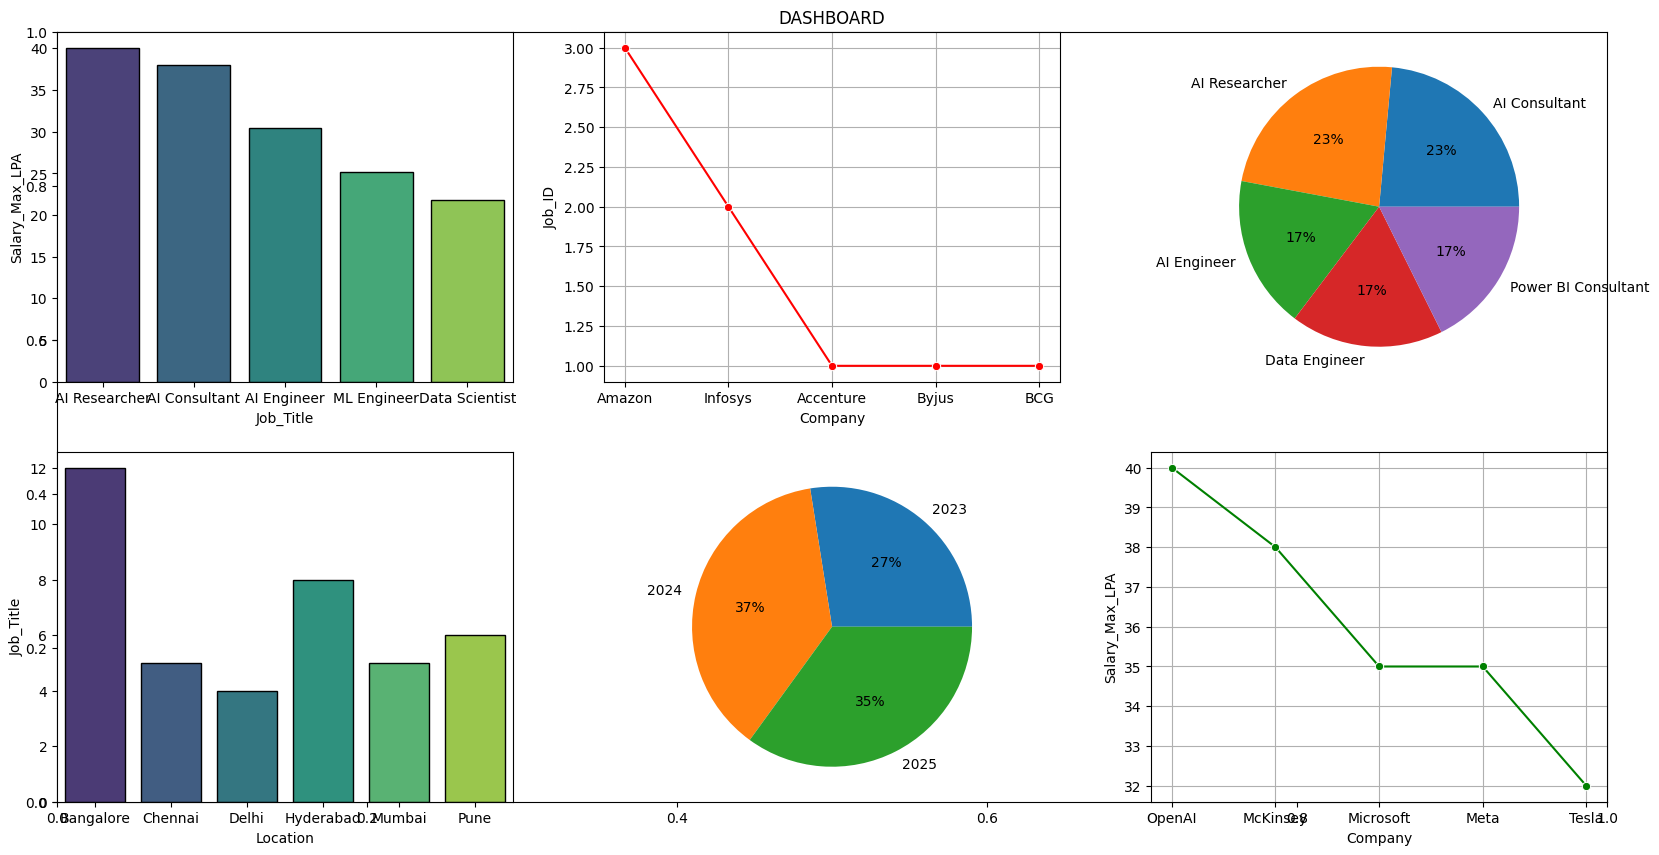

In [16]:
plt.figure(figsize=(20,10))
plt.title("DASHBOARD")
plt.subplot(2,3,1)
sns.barplot(x="Job_Title",y="Salary_Max_LPA",data=da,palette="viridis",edgecolor="black")
plt.subplot(2,3,2)
sns.lineplot(x="Company",y="Job_ID",data=db,color="red",marker="o")
plt.grid(True)
plt.subplot(2,3,3)
plt.pie(dc.values,labels=dc.index,autopct="%1d%%")
plt.subplot(2,3,4)
sns.barplot(x="Location",y="Job_Title",data=de,palette="viridis",edgecolor="black")
plt.subplot(2,3,5)
plt.pie(dg.values,labels=dg.index,autopct="%1d%%")
plt.subplot(2,3,6)
sns.lineplot(x="Company",y="Salary_Max_LPA",data=di,color="green",marker="o")
plt.grid(True)
plt.show()

# DATA STORY TELLING

### AI Researchers are the highest paid job.
### Amazon is providing more jobs.
### AI Consultant role requires highest experience.
### Banglore location has the maximum vacancies.
### 2024 has more vacancies than other years.
### OpenAI provide more salary than other companies.

In [17]:
df.dtypes

Job_ID                       int64
Job_Title                      str
Job_Category                   str
Location                       str
Year                         int64
Company                        str
Experience_Required_Years    int64
Salary_Min_LPA               int64
Salary_Max_LPA               int64
Employment_Type                str
dtype: object

# Using MLMODEL to predict output

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Define Features & Target

X = df[[
    "Job_ID",              
    "Year",            
    "Experience_Required_Years"      
]]

y = df["Salary_Min_LPA"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

# Model selection
model = RandomForestRegressor()

# Train Model
model.fit(X_train, y_train)

# Predictions
y_preds = model.predict(X_test)
print(y_preds)
#Evaluation
print("R² Score:", r2_score(y_test, y_preds))


[11.84 17.25  3.87 10.76  4.03 13.47  5.74  7.45]
R² Score: 0.7026624271330153
